In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [5]:
df = pd.read_csv(r"C:\project 4\Spotify Analysis\hindi_bollywood_spotify_100k.csv")

In [4]:
df.head()

,track_name,artist,genre,popularity,danceability,energy,loudness,tempo,valence,duration_ms
0,Hindi_Song_0,KK,Romantic,85,0.560,0.346,-31.06,169.45,0.387,263206
1,Hindi_Song_1,Neha Kakkar,Indie,71,0.467,0.872,-22.34,97.06,0.276,320707
2,Hindi_Song_2,Udit Narayan,Sad,23,0.779,0.638,-36.83,141.66,0.236,229959
3,Hindi_Song_3,Darshan Raval,Folk,85,0.604,0.348,-15.49,96.60,0.252,127598
4,Hindi_Song_4,Diljit Dosanjh,Bollywood,59,0.766,0.334,-7.15,155.56,0.249,151758


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   track_name    100000 non-null  object 
 1   artist        100000 non-null  object 
 2   genre         100000 non-null  object 
 3   popularity    100000 non-null  int64  
 4   danceability  100000 non-null  float64
 5   energy        100000 non-null  float64
 6   loudness      100000 non-null  float64
 7   tempo         100000 non-null  float64
 8   valence       100000 non-null  float64
 9   duration_ms   100000 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 7.6+ MB
None


 Data Cleaning

In [8]:
# Remove duplicates
df = df.drop_duplicates()

In [9]:
# Handle missing values
df = df.dropna()

In [10]:
# Convert duration (if exists)
if 'duration_ms' in df.columns:
    df['duration_min'] = df['duration_ms'] / 60000


In [11]:
# Create popularity category
def popularity_level(x):
    if x < 40:
        return 'Low'
    elif x < 70:
        return 'Medium'
    else:
        return 'High'

df['popularity_level'] = df['popularity'].apply(popularity_level)


EDA (Exploratory Analysis)

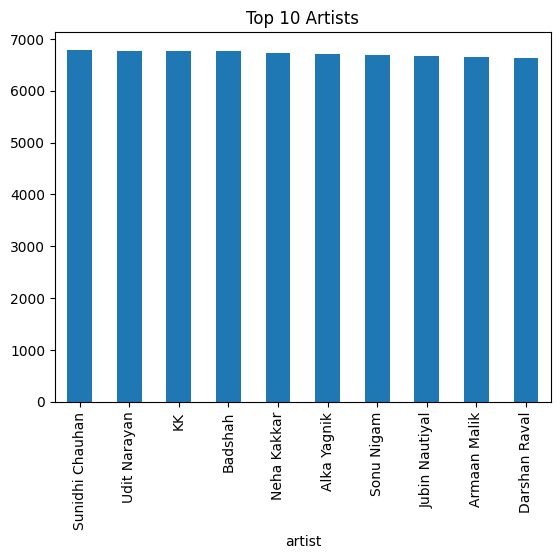

In [12]:
# Top Artists
top_artists = df['artist'].value_counts().head(10)

plt.figure()
top_artists.plot(kind='bar')
plt.title("Top 10 Artists")
plt.show()

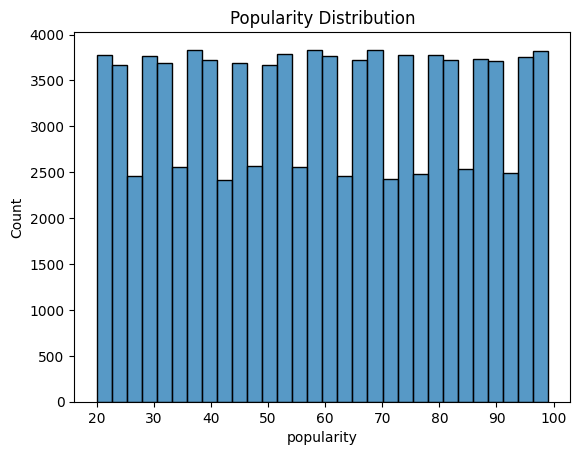

In [13]:
# Popularity Distribution
plt.figure()
sns.histplot(df['popularity'], bins=30)
plt.title("Popularity Distribution")
plt.show()

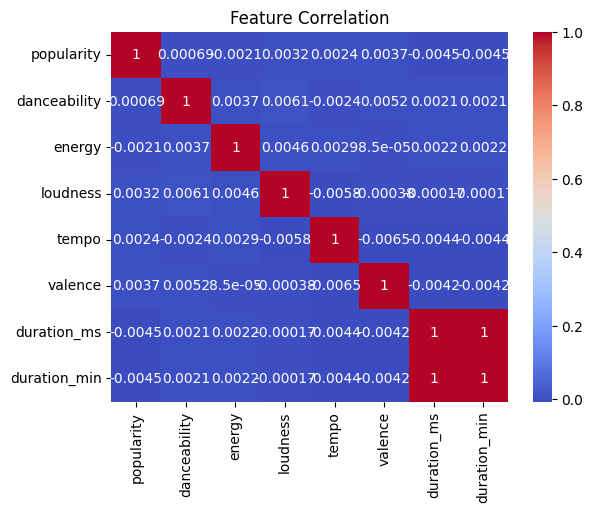

In [14]:
# Correlation Heatmap
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

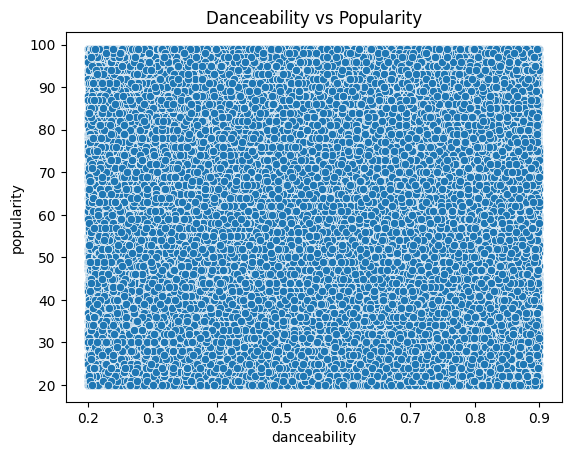

In [15]:
# Danceability vs Popularity
plt.figure()
sns.scatterplot(x='danceability', y='popularity', data=df)
plt.title("Danceability vs Popularity")
plt.show()


Save Clean Data

In [16]:
import os

# Create 'data' folder if not exists
os.makedirs('data', exist_ok=True)

# Now save file
df.to_csv('data/clean_spotify.csv', index=False)

print(" Data cleaned and saved!")

 Data cleaned and saved!


In [17]:
# Song duration category
df['duration_min'] = df['duration_ms'] / 60000

df['duration_category'] = pd.cut(
    df['duration_min'],
    bins=[0, 2, 4, 10],
    labels=['Short', 'Medium', 'Long']
)

In [18]:
print(df.columns)

Index(['track_name', 'artist', 'genre', 'popularity', 'danceability', 'energy',
       'loudness', 'tempo', 'valence', 'duration_ms', 'popularity_level',
       'duration_min', 'duration_category'],
      dtype='object')


In [19]:
# Mood classification using valence
df['mood'] = df['valence'].apply(lambda x: 'Happy' if x > 0.6 else 'Sad')

In [20]:
# Energy level classification
df['energy_level'] = pd.cut(
    df['energy'],
    bins=[0, 0.4, 0.7, 1],
    labels=['Low', 'Medium', 'High']
)

Advanced EDA

Genre vs Popularity

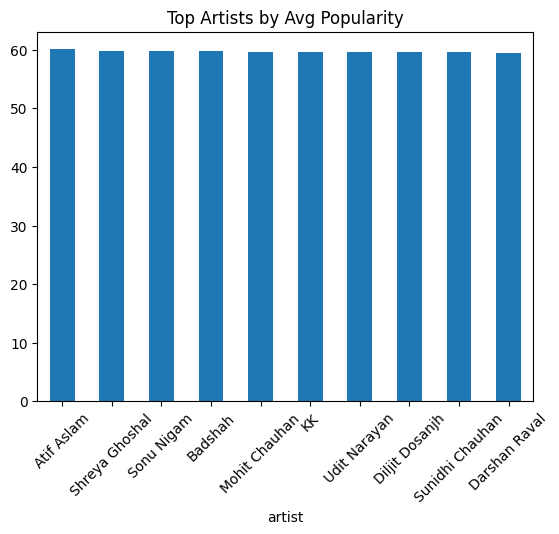

In [21]:
top_artists = df.groupby('artist')['popularity'].mean().sort_values(ascending=False).head(10)

plt.figure()
top_artists.plot(kind='bar')
plt.title("Top Artists by Avg Popularity")
plt.xticks(rotation=45)
plt.show()

Genre vs Popularity

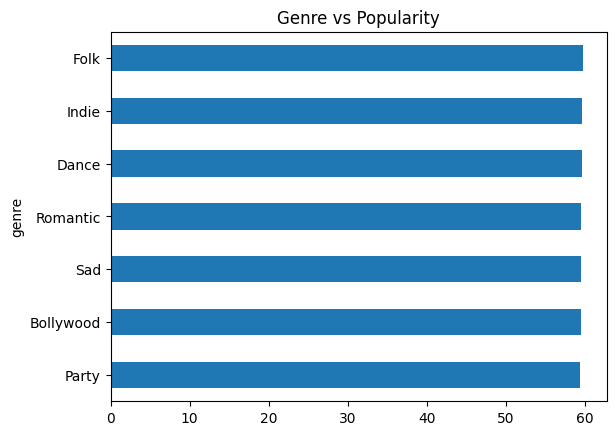

In [22]:
genre_pop = df.groupby('genre')['popularity'].mean().sort_values()

plt.figure()
genre_pop.plot(kind='barh')
plt.title("Genre vs Popularity")
plt.show()

Mood Distribution

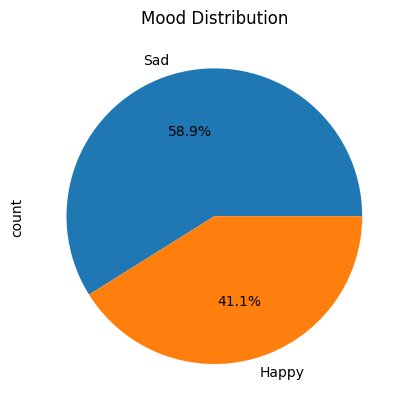

In [23]:
plt.figure()
df['mood'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Mood Distribution")
plt.show()

Energy vs Popularity

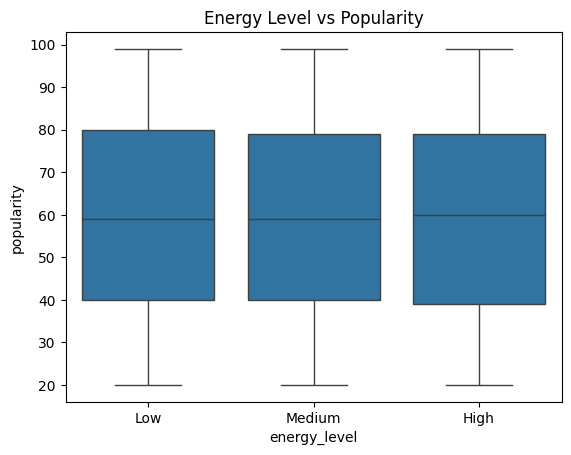

In [24]:
plt.figure()
sns.boxplot(x='energy_level', y='popularity', data=df)
plt.title("Energy Level vs Popularity")
plt.show()

Correlation Deep Analysis

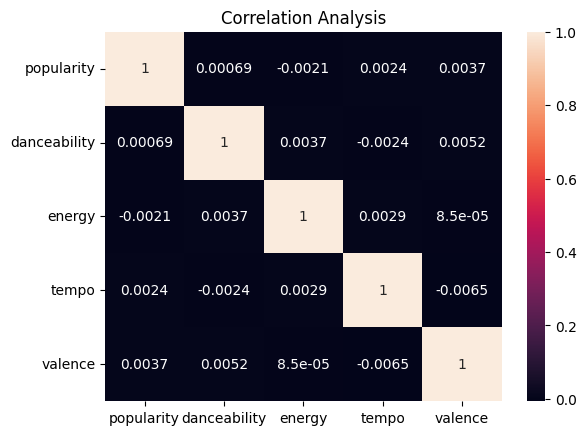

In [25]:
corr = df[['popularity','danceability','energy','tempo','valence']].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Analysis")
plt.show()

Hypothesis Testing

In [26]:
high_energy = df[df['energy'] > 0.7]['popularity']
low_energy = df[df['energy'] <= 0.7]['popularity']

from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(high_energy, low_energy)

print("P-value:", p_value)

P-value: 0.6103148048486522


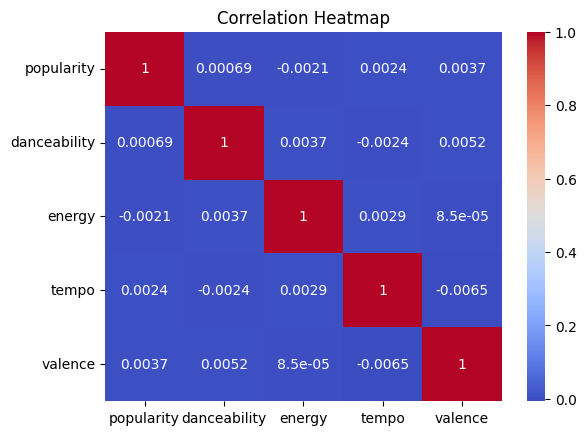

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['popularity','danceability','energy','tempo','valence']].corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")

plt.savefig('heatmap.png')
plt.show()